# ❄️ Snow Water Equivalent Reconstruction

<center>
  <img src="images/15Advanced_LTC2026_KV_final.png" width="60%">
</center>

**Course website:**  
https://eo4society.esa.int/event/15th-advanced-training-course-on-land-remote-sensing-the-water-cycle/

**Instructors:** Carlo Marin and Valentina Premier, Eurac Research

---
## Overview

In this notebook, you will reconstruct **Snow Water Equivalent (SWE)** over the Lo Aguirre study area. You will learn about the meteorological inputs and remote sensing data needed for SWE reconstruction, become familiar with the **Enhanced Temperature Index (ETI) model**, and explore the sensitivity of the main parameters that are typically tuned during SWE reconstruction.

The workflow follows the approach presented by [Premier et al. (2023)](https://tc.copernicus.org/articles/17/2387/2023/).

## Learning Objectives

By the end of this notebook, you will be able to:

* Understand the input data required for SWE reconstruction.
* Become familiar with the **Enhanced Temperature Index (ETI) model**.
* Explore the sensitivity of the model to different parameter values.
* Tune the **temperature and radiation factors** used for SWE reconstruction.

---

## 1. Setup

First, run the import cell below.

If you receive a `ModuleNotFoundError`:

1. uncomment and run the installation cell;
2. restart the kernel;
3. run the notebook again from the beginning.

If all imports work, skip the installation cell.

In [1]:
# %pip install pystac-client stackstac xarray dask pandas matplotlib

In [30]:
import contextlib
import gc
import io
from time import perf_counter
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import leafmap
import numpy as np

import pandas as pd
import stackstac
import xarray as xr
import rioxarray as rxr
from pystac_client import Client

from utils import load_stac_cube

# Locate the repository and tutorial-data folders.
WORKDIR = Path.cwd()
ROOT = WORKDIR.parent
TUTORIAL_DIR = ROOT / "eotraining"

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(TUTORIAL_DIR))

from melting import (
    compute_state_and_accumulation,
    get_melt_pomeroy,
    get_swe,
)



plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
})

## 2. Select a hydrological year

In this Southern Hemisphere exercise, a hydrological year starts on **1 April** and ends on **31 March** of the following calendar year. For this tutorial, we have prepared data covering the season 2022/23.

In [3]:
HY_START_YEAR = 2022  # Selects 2022-04-01 through 2023-03-31

DATE_START = f"{HY_START_YEAR}-04-01"
DATE_END = f"{HY_START_YEAR + 1}-03-31"

HYDROLOGICAL_YEAR = f"HY{HY_START_YEAR}/{HY_START_YEAR + 1}"

print(f"Selected {HYDROLOGICAL_YEAR}: {DATE_START} to {DATE_END}")

Selected HY2022/2023: 2022-04-01 to 2023-03-31


Load the **Digital Elevation Model (DEM)**.

In [4]:
DEM_PATH = TUTORIAL_DIR / "DEM.tif"

dem = (
  rxr.open_rasterio(DEM_PATH, masked=True)
  .squeeze("band", drop=True)
  .rename("elevation")
)

EXTENT = dem.rio.bounds()
RESOLUTION = dem.rio.resolution()
EPSG = dem.rio.crs.to_epsg()

## 3. Load the Meteorological Input Data from STAC

We have pre-prepared some **meteorological forcing data** (air temperature and shortwave radiation) as STAC collections. These data will be used as input to the **Enhanced Temperature Index (ETI) model**.

If you are interested in the downscaling procedure used to generate these meteorological fields, have a look at the [micropyzzotmet repository](https://github.com/bare92/micropyzzotmet), which implements a **MicroMet-inspired workflow**.

The approach is based on:

> Liston, G. E., & Elder, K. (2006). *A Meteorological Distribution System for High-Resolution Terrestrial Modeling (MicroMet).* Journal of Hydrometeorology, 7(2), 217–234.  
> https://doi.org/10.1175/JHM486.1

### 3.1 Temperature Data

In [5]:
STAC_API = "https://stac.openeo.eurac.edu/api/v1/pgstac/"
TEMPERATURE_COLLECTION = "LoAguirre_temperature"


catalog = Client.open(STAC_API)

items = catalog.search(
  collections=[TEMPERATURE_COLLECTION],
  datetime=f"{DATE_START}/{DATE_END}",
).item_collection()

print(f"Found {len(items)} items")

temperature = (
  stackstac.stack(
      items,
      assets=["t2m"],
      epsg=EPSG,
      resolution=RESOLUTION[0],
      bounds=EXTENT,
      xy_coords="center",
  )
  .squeeze("band", drop=True)
  .sortby("time")
)

temperature

Found 365 items


<xarray.DataArray 'stackstac-c308dcfb5130a916d5c848cc30a3f80a' (time: 365,
                                                                y: 400, x: 400)> Size: 467MB
dask.array<getitem, shape=(365, 400, 400), dtype=float64, chunksize=(1, 400, 400), chunktype=numpy.ndarray>
Coordinates: (12/14)
  * time                 (time) datetime64[ns] 3kB 2022-04-01 ... 2023-03-31
  * y                    (y) float64 3kB 6.022e+06 6.022e+06 ... 6.014e+06
  * x                    (x) float64 3kB 3.54e+05 3.54e+05 ... 3.62e+05 3.62e+05
    id                   (time) <U14 20kB '20220401000000' ... '20230331000000'
    transform            object 8B {0.0, 1.0, -20.0, 6022000.0, 354000.0, 20.0}
    geometry             object 8B {'type': 'Polygon', 'coordinates': [[[3540...
    ...                   ...
    projjson             object 8B {'id': {'code': 32719, 'authority': 'EPSG'...
    shape                object 8B {400}
    bbox                 object 8B {354000.0, 362000.0, 6014000.0, 6022000.0}
    common_name          object 8B None
    center_wavelength    object 8B None
    full_width_half_max  object 8B None
Attributes:
    spec:        RasterSpec(epsg=32719, bounds=(354000.0, 6014000.0, 362000.0...
    crs:         epsg:32719
    transform:   | 20.00, 0.00, 354000.00|\n| 0.00,-20.00, 6022000.00|\n| 0.0...
    resolution:  20.0

#### Load the raster values

The previous cell created a **lazy data cube** containing only the instructions needed to read each scene.

The following cell downloads the pixel values because the conditional-probability calculations require the 

In [6]:
temperature = load_stac_cube(
    temperature.astype("float32"), "temperature"
)

print("Dimensions:", dict(temperature.sizes))
print(f"Memory used: {temperature.nbytes / 1e6:.1f} MB")

Dimensions: {'time': 365, 'y': 400, 'x': 400}
Memory used: 233.6 MB


#### Mean temperature over the study area

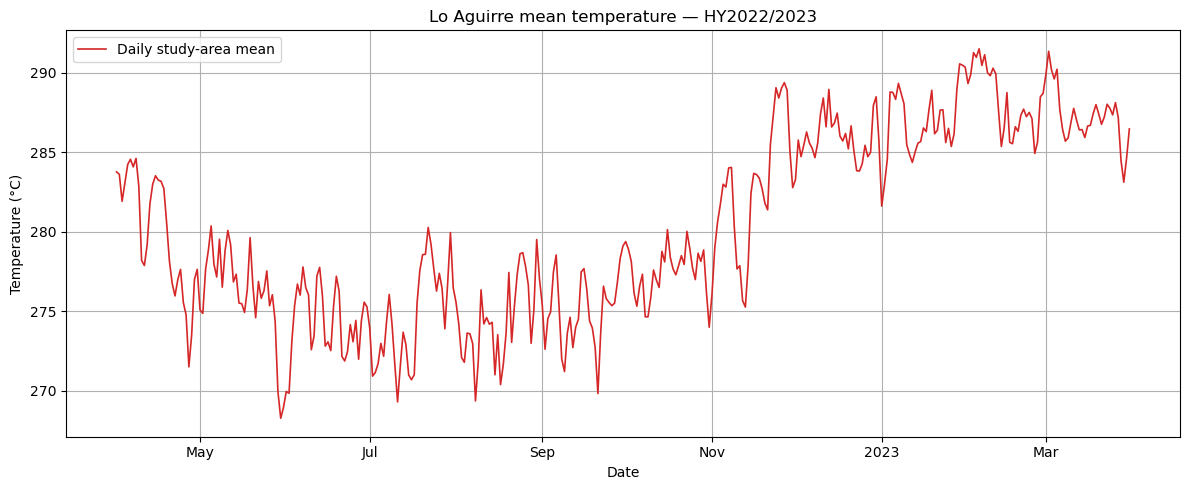

In [9]:
area_mean_temperature = (
    temperature
    .mean(dim=("y", "x"), skipna=True)
    .compute()
)

fig, ax = plt.subplots()

area_mean_temperature.plot(
    ax=ax,
    color="tab:red",
    linewidth=1.2,
    label="Daily study-area mean",
)

ax.set(
    title=f"Lo Aguirre mean temperature — {HYDROLOGICAL_YEAR}",
    xlabel="Date",
    ylabel="Temperature (°C)",
)

ax.legend()
fig.tight_layout()
plt.show()

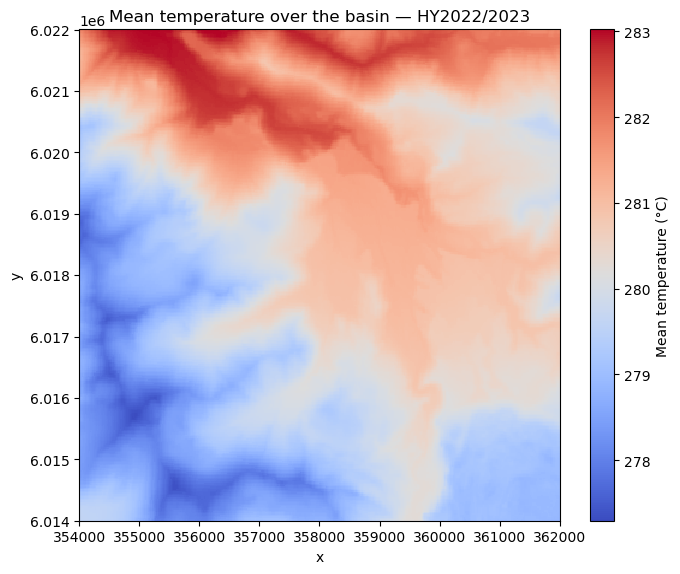

In [10]:
mean_temperature_map = (
    temperature
    .mean(dim="time", skipna=True)
    .compute()
)

fig, ax = plt.subplots(figsize=(7, 6))

mean_temperature_map.plot(
    ax=ax,
    cmap="coolwarm",
    cbar_kwargs={
        "label": "Mean temperature (°C)"
    },
)

ax.set_title(
    f"Mean temperature over the basin — {HYDROLOGICAL_YEAR}"
)

ax.set_xlabel("x")
ax.set_ylabel("y")

fig.tight_layout()
plt.show()

### 3.1 Shortwave Radiation Data

In [16]:
STAC_API = "https://stac.openeo.eurac.edu/api/v1/pgstac/"
SW_COLLECTION = "LoAguirre_SW"


catalog = Client.open(STAC_API)

items = catalog.search(
  collections=[SW_COLLECTION],
  datetime=f"{DATE_START}/{DATE_END}",
).item_collection()

print(f"Found {len(items)} items")

SW = (
  stackstac.stack(
      items,
      assets=["SW"],
      epsg=EPSG,
      resolution=RESOLUTION[0],
      bounds=EXTENT,
      xy_coords="center",
  )
  .squeeze("band", drop=True)
  .sortby("time")
)

SW

Found 365 items


<xarray.DataArray 'stackstac-d1d2d06a94095a263c57b03e7306d50d' (time: 365,
                                                                y: 400, x: 400)> Size: 467MB
dask.array<getitem, shape=(365, 400, 400), dtype=float64, chunksize=(1, 400, 400), chunktype=numpy.ndarray>
Coordinates: (12/14)
  * time                 (time) datetime64[ns] 3kB 2022-04-01 ... 2023-03-31
  * y                    (y) float64 3kB 6.022e+06 6.022e+06 ... 6.014e+06
  * x                    (x) float64 3kB 3.54e+05 3.54e+05 ... 3.62e+05 3.62e+05
    id                   (time) <U14 20kB '20220401000000' ... '20230331000000'
    transform            object 8B {0.0, 1.0, -20.0, 6022000.0, 354000.0, 20.0}
    geometry             object 8B {'type': 'Polygon', 'coordinates': [[[3540...
    ...                   ...
    projjson             object 8B {'id': {'code': 32719, 'authority': 'EPSG'...
    shape                object 8B {400}
    bbox                 object 8B {354000.0, 362000.0, 6014000.0, 6022000.0}
    common_name          object 8B None
    center_wavelength    object 8B None
    full_width_half_max  object 8B None
Attributes:
    spec:        RasterSpec(epsg=32719, bounds=(354000.0, 6014000.0, 362000.0...
    crs:         epsg:32719
    transform:   | 20.00, 0.00, 354000.00|\n| 0.00,-20.00, 6022000.00|\n| 0.0...
    resolution:  20.0

#### Load the raster values

In [12]:
SW = load_stac_cube(SW.astype("float32"), "shortwave radiation")

print("Dimensions:", dict(SW.sizes))
print(f"Memory used: {SW.nbytes / 1e6:.1f} MB")

Dimensions: {'time': 365, 'y': 400, 'x': 400}
Memory used: 233.6 MB


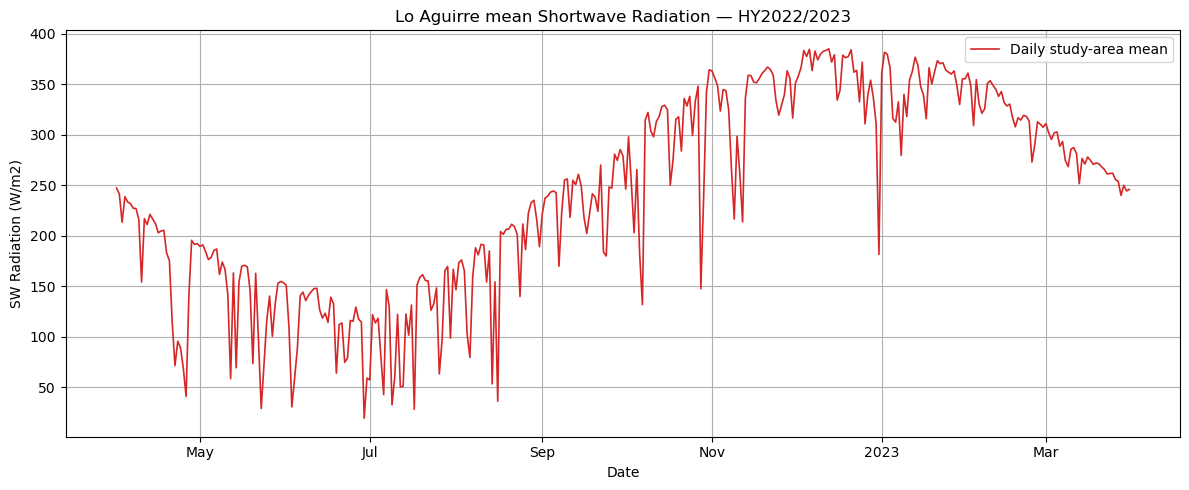

In [15]:
area_mean_SW = (
    SW
    .mean(dim=("y", "x"), skipna=True)
    .compute()
)

fig, ax = plt.subplots()
area_mean_SW.plot(
    ax=ax,
    color="tab:red",
    linewidth=1.2,
    label="Daily study-area mean",
)

ax.set(
    title=f"Lo Aguirre mean Shortwave Radiation — {HYDROLOGICAL_YEAR}",
    xlabel="Date",
    ylabel="SW Radiation (W/m2)",
)
ax.legend()
fig.tight_layout()
plt.show()

### 3.1 Precipitation Data

Precipitation is not downscaled; instead, we retain the original coarse-resolution ERA5 field, since we are mainly interested in identifying **where and when precipitation occurred**, rather than in accurately estimating the precipitation amount.

In [17]:
STAC_API = "https://stac.openeo.eurac.edu/api/v1/pgstac/"
PRECIPITATION_COLLECTION = "LoAguirre_precipitation"


catalog = Client.open(STAC_API)

items = catalog.search(
  collections=[PRECIPITATION_COLLECTION],
  datetime=f"{DATE_START}/{DATE_END}",
).item_collection()

print(f"Found {len(items)} items")

precipitation = (
  stackstac.stack(
      items,
      assets=["tp"],
      epsg=EPSG,
      resolution=RESOLUTION[0],
      bounds=EXTENT,
      xy_coords="center",
  )
  .squeeze("band", drop=True)
  .sortby("time")
)

precipitation

Found 365 items


<xarray.DataArray 'stackstac-f878611fb37cb732aedb8bd38ec1c51b' (time: 365,
                                                                y: 400, x: 400)> Size: 467MB
dask.array<getitem, shape=(365, 400, 400), dtype=float64, chunksize=(1, 400, 400), chunktype=numpy.ndarray>
Coordinates: (12/14)
  * time                 (time) datetime64[ns] 3kB 2022-04-01 ... 2023-03-31
  * y                    (y) float64 3kB 6.022e+06 6.022e+06 ... 6.014e+06
  * x                    (x) float64 3kB 3.54e+05 3.54e+05 ... 3.62e+05 3.62e+05
    id                   (time) <U14 20kB '20220401000000' ... '20230331000000'
    transform            object 8B {0.10000000000002274, 0.0, -0.100000000000...
    geometry             object 8B {'type': 'Polygon', 'coordinates': [[[-71....
    ...                   ...
    projjson             object 8B {'id': {'code': 4326, 'authority': 'EPSG'}...
    shape                object 8B {9}
    bbox                 object 8B {-71.0500000000028, -70.15000000000259, -3...
    common_name          object 8B None
    center_wavelength    object 8B None
    full_width_half_max  object 8B None
Attributes:
    spec:        RasterSpec(epsg=32719, bounds=(354000.0, 6014000.0, 362000.0...
    crs:         epsg:32719
    transform:   | 20.00, 0.00, 354000.00|\n| 0.00,-20.00, 6022000.00|\n| 0.0...
    resolution:  20.0

#### Load the raster values

In [18]:
precipitation = load_stac_cube(
    precipitation.astype("float32"), "precipitation"
)

print("Dimensions:", dict(precipitation.sizes))
print(f"Memory used: {precipitation.nbytes / 1e6:.1f} MB")

Dimensions: {'time': 365, 'y': 400, 'x': 400}
Memory used: 233.6 MB


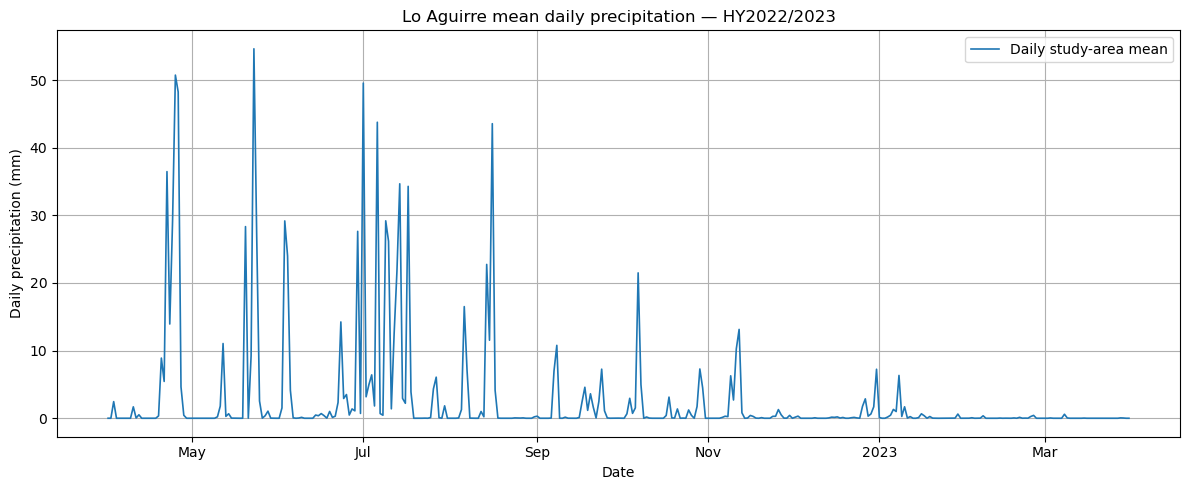

In [21]:
area_mean_precipitation = (
    precipitation
    .mean(dim=("y", "x"), skipna=True)
    .compute()
)

fig, ax = plt.subplots()
area_mean_precipitation.plot(
    ax=ax,
    color="tab:blue",
    linewidth=1.2,
    label="Daily study-area mean",
)

ax.set(
    title=f"Lo Aguirre mean daily precipitation — {HYDROLOGICAL_YEAR}",
    xlabel="Date",
    ylabel="Daily precipitation (mm)",
)
ax.legend()
fig.tight_layout()
plt.show()

## 3. Load the Snow Cover Data from STAC

This is a daily high-resolution Snow-Covered Area (SCA) time series obtained using the approach developed by [Premier et al. (2021)](https://ieeexplore.ieee.org/document/9511108) (see the previous tutorial).

In addition, a **harmonization procedure** is applied to the SCA time series. Pixel transitions are corrected based on the pixel **status**: a melting pixel cannot transition from snow-free to snow, while an accumulating pixel cannot transition from snow to snow-free.

For the purpose of this tutorial, the harmonization has already been applied using the above-mentioned meteorological variables to determine the pixel status.

For more information on the harmonization procedure, see [Premier et al. (2023)](https://tc.copernicus.org/articles/17/2387/2023/).

In [22]:
STAC_API = "https://stac.openeo.eurac.edu/api/v1/pgstac/"
SCA_COLLECTION = "LoAguirre_daily_sca"


catalog = Client.open(STAC_API)

items = catalog.search(
  collections=[SCA_COLLECTION],
  datetime=f"{DATE_START}/{DATE_END}",
).item_collection()

print(f"Found {len(items)} items")

SCA = (
  stackstac.stack(
      items,
      assets=["SCA"],
      epsg=EPSG,
      resolution=RESOLUTION[0],
      bounds=EXTENT,
      xy_coords="center",
  )
  .squeeze("band", drop=True)
  .sortby("time")
)

SCA

Found 365 items


<xarray.DataArray 'stackstac-6b9a0999252c027820d4cdd598fdbe79' (time: 365,
                                                                y: 400, x: 400)> Size: 467MB
dask.array<getitem, shape=(365, 400, 400), dtype=float64, chunksize=(1, 400, 400), chunktype=numpy.ndarray>
Coordinates: (12/14)
  * time                 (time) datetime64[ns] 3kB 2022-04-01 ... 2023-03-31
  * y                    (y) float64 3kB 6.022e+06 6.022e+06 ... 6.014e+06
  * x                    (x) float64 3kB 3.54e+05 3.54e+05 ... 3.62e+05 3.62e+05
    id                   (time) <U14 20kB '20220401000000' ... '20230331000000'
    transform            object 8B {0.0, 1.0, -20.0, 6022000.0, 354000.0, 20.0}
    geometry             object 8B {'type': 'Polygon', 'coordinates': [[[3540...
    ...                   ...
    projjson             object 8B {'id': {'code': 32719, 'authority': 'EPSG'...
    shape                object 8B {400}
    bbox                 object 8B {354000.0, 362000.0, 6014000.0, 6022000.0}
    common_name          object 8B None
    center_wavelength    object 8B None
    full_width_half_max  object 8B None
Attributes:
    spec:        RasterSpec(epsg=32719, bounds=(354000.0, 6014000.0, 362000.0...
    crs:         epsg:32719
    transform:   | 20.00, 0.00, 354000.00|\n| 0.00,-20.00, 6022000.00|\n| 0.0...
    resolution:  20.0

In [23]:
SCA = load_stac_cube(SCA.astype("float32"), "daily SCA")

print("Dimensions:", dict(SCA.sizes))
print(f"Memory used: {SCA.nbytes / 1e6:.1f} MB")

Dimensions: {'time': 365, 'y': 400, 'x': 400}
Memory used: 233.6 MB


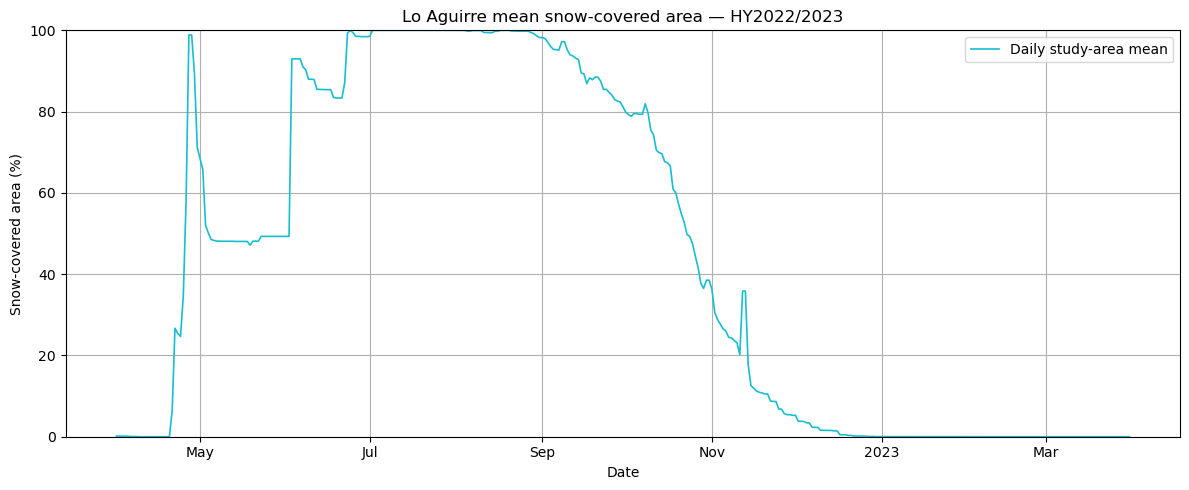

In [24]:
valid_SCA = SCA.where((SCA >= 0) & (SCA <= 100))

area_mean_SCA = (
    valid_SCA
    .mean(dim=("y", "x"), skipna=True)
    .compute()
)

fig, ax = plt.subplots()
area_mean_SCA.plot(
    ax=ax,
    color="tab:cyan",
    linewidth=1.2,
    label="Daily study-area mean",
)

ax.set(
    title=f"Lo Aguirre mean snow-covered area — {HYDROLOGICAL_YEAR}",
    xlabel="Date",
    ylabel="Snow-covered area (%)",
    ylim=(0, 100),
)
ax.legend()
fig.tight_layout()
plt.show()


## 4. SWE Reconstruction

We will now perform the **Snow Water Equivalent (SWE) reconstruction**. The model identifies accumulation and melt conditions based on air temperature and precipitation:

- **Accumulation** occurs when the temperature is lower than `ACCUMULATION_TEMPERATURE` and precipitation is higher than `PRECIPITATION_THRESHOLD`.
- **Melting** occurs when the temperature is higher than `ACCUMULATION_TEMPERATURE`.

The model then computes the **potential snowmelt** from an **Enhanced Temperature Index (ETI)** model, i.e., from a temperature and a shortwave-radiation term. SWE is subsequently reconstructed while being constrained by the observed Snow-Covered Area (SCA).

### Potential Snowmelt

Potential snowmelt is calculated as:

$$
M(t,x,y) =
\mathrm{TF} \cdot T(t,x,y)
+
\mathrm{SRF} \cdot SW(t,x,y) \cdot \left[1-\alpha(t,x,y)\right]
$$

where:

- $M(t,x,y)$ is the potential snowmelt;
- $T(t,x,y)$ is the air temperature;
- $SW(t,x,y)$ is the incoming shortwave radiation;
- $\alpha(t,x,y)$ is the snow albedo;
- `TF` is the **temperature factor** (or degree-day factor);
- `SRF` is the **shortwave-radiation factor**.

The parameters `TF` and `SRF` therefore control the relative contributions of air temperature and shortwave radiation to snowmelt.

### Snow Albedo

Snow albedo $\alpha$ is calculated following the parameterization of [Bertoncini and Pomeroy (2024)](https://doi.org/10.1002/hyp.15329). The albedo after snowfall is estimated as:

$$
\alpha =
\alpha_{\mathrm{dry}}
+
(\alpha_{\max} - \alpha_{\mathrm{dry}})
\frac{S_t}{S_{\min}}
$$

where:

- $\alpha_{\max}$ is the maximum snow albedo (0.90);
- $S_t$ is the snowfall rate;
- $S_{\min}$ is the minimum snowfall rate required to restore the snow albedo to $\alpha_{\max}$ (10 mm $\mathrm{h}^{-1}$).

The resulting $\alpha$ is constrained between the minimum snow albedo, $\alpha_{\min}$=0.60, and the maximum snow albedo, $\alpha_{\max}$=0.90.

#### Dry-Snow Albedo Decay

When the air temperature is below 0$^\circ\mathrm{C}$, the dry-snow albedo is calculated from the albedo at the previous time step:

$$
\alpha_{\mathrm{dry}}(t) =
\alpha (t-1) - d_{\mathrm{dry}}
$$

where $d_{\mathrm{dry}}$ = 0.0003 $\mathrm{h}^{-1}$ is the dry-snow albedo decay constant.

#### Wet-Snow Albedo Decay

When the air temperature is at or above 0$^\circ\mathrm{C}$, wet-snow conditions are assumed and the albedo is calculated as:

$$
\alpha_{\mathrm{wet}}(t)=
(\alpha_{m}(t-1) - \alpha_{\min})\exp(-d_{\mathrm{wet}})+
\alpha_{\min}
$$

where $d_{\mathrm{wet}}$ = 0.005 $\mathrm{h}^{-1}$ is the wet-snow albedo decay constant.

### Prepare the STAC inputs

All four STAC cubes were loaded on the DEM grid. We retain only their dimension coordinates, align their common dates, convert temperature from Kelvin to degrees Celsius, and give each array the variable name expected by the reconstruction functions.

In [28]:
def model_array(data, name):
    """Keep dimension coordinates and assign the model variable name."""
    return data.reset_coords(drop=True).rename(name)


# Materialize inputs here as well. This keeps the reconstruction section
# safe if a STAC query cell was rerun after its earlier loading cell.
SCA_input = model_array(load_stac_cube(SCA, "daily SCA"), "SCA")
temperature_input = model_array(
    load_stac_cube(temperature, "temperature"), "t2m"
)
SW_input = model_array(
    load_stac_cube(SW, "shortwave radiation"), "SW"
)
precipitation_input = model_array(
    load_stac_cube(precipitation, "precipitation"), "tp"
)

SCA_input, temperature_input, SW_input, precipitation_input = xr.align(
    SCA_input,
    temperature_input,
    SW_input,
    precipitation_input,
    join="inner",
)

expected_days = (pd.Timestamp(DATE_END) - pd.Timestamp(DATE_START)).days + 1
if SCA_input.sizes["time"] != expected_days:
    raise ValueError(
        f"Expected {expected_days} common daily observations, found "
        f"{SCA_input.sizes['time']}"
    )

temperature_input = temperature_input - 273.15
temperature_input.attrs["units"] = "°C"

SCA_model = SCA_input.to_dataset(name="SCA")
temperature_model = temperature_input.to_dataset(name="t2m")
SW_model = SW_input.to_dataset(name="SW")
if not (
    np.array_equal(SCA_input.x.values, dem.x.values)
    and np.array_equal(SCA_input.y.values, dem.y.values)
):
    raise ValueError("The STAC and DEM pixel-centre coordinates do not match")

domain_mask = dem.notnull().reset_coords(drop=True)

print("Model dimensions:", dict(SCA_model.sizes))
print("Temperature units:", temperature_input.attrs["units"])
print("Precipitation units: mm/day")
print("Shortwave-radiation units: W m⁻²")

Model dimensions: {'time': 365, 'x': 400, 'y': 400}
Temperature units: °C
Precipitation units: mm/day
Shortwave-radiation units: W m⁻²


### Identify accumulation and melt conditions

We calculate the `status` that represents whether a pixel is in accumulation or melting. The normalized precipitation fraction `delta` distributes the inferred accumulation through time. 

In [29]:
ACCUMULATION_TEMPERATURE = 2.0  # °C
PRECIPITATION_THRESHOLD = 2.0  # mm/day

status = xr.where(
    (temperature_input < ACCUMULATION_TEMPERATURE)
    & (precipitation_input > PRECIPITATION_THRESHOLD),
    1,
    -1,
).astype("int8")

accumulation_precipitation = precipitation_input.where(status == 1)
total_accumulation = accumulation_precipitation.sum(dim="time")
delta = (
    accumulation_precipitation
    / total_accumulation.where(total_accumulation > 0)
).fillna(0).astype("float32")

status = status.load()
delta = delta.load()

accumulation_fraction = float((status == 1).mean().item())
print(f"Accumulation conditions: {accumulation_fraction:.1%} of pixel-days")

Accumulation conditions: 8.8% of pixel-days


### Define and run melt-factor scenarios

The factor values are consistent with those used in [Ayala et al. (2020)](https://tc.copernicus.org/articles/14/2005/2020/#&gid=1&pid=1).

Change the values below, add a new scenario, or remove one of the existing scenarios, then rerun the following cells to explore the **sensitivity of the model** to the selected parameter values.


In [31]:
MELT_SCENARIOS = {
    "Low melt": {"TF": 0.18, "SRF": 0.10},
    "Mid melt": {"TF": 0.24, "SRF": 0.15},
    "High melt": {"TF": 0.30, "SRF": 0.20},
}

scenario_results = {}
scenario_summary = []

for scenario, factors in MELT_SCENARIOS.items():
    started = perf_counter()
    print(
        f"Running {scenario}: TF={factors['TF']}, "
        f"SRF={factors['SRF']}"
    )

    # The model functions print every processed date; suppress those messages
    # here so that scenario-level progress remains readable.
    with contextlib.redirect_stdout(io.StringIO()):
        melt = get_melt_pomeroy(
            SCA_model,
            temperature_model,
            precipitation_input,
            SW_model,
            status,
            TF=factors["TF"],
            SRF=factors["SRF"],
            T_thresh=0.0,
        )
        sca_sum, total_melt = compute_state_and_accumulation(
            SCA_model, melt, status, delta
        )
        swe_values = get_swe(
            SCA_model, melt, status, delta, sca_sum, total_melt
        )

    SWE = xr.DataArray(
        swe_values,
        dims=("time", "y", "x"),
        coords={
            "time": SCA_input.time,
            "y": SCA_input.y,
            "x": SCA_input.x,
        },
        name="SWE",
        attrs={"units": "mm"},
    ).where(domain_mask)

    mean_SWE = SWE.mean(dim=("y", "x"), skipna=True)
    if bool(mean_SWE.isnull().all().item()):
        raise ValueError(
            "The reconstructed SWE contains no valid study-area pixels. "
            "Check the SCA values and spatial-grid coordinates."
        )
    peak_index = int(mean_SWE.argmax(skipna=True).item())
    peak_date = pd.Timestamp(SWE.time.isel(time=peak_index).values)
    peak_mean_SWE = float(mean_SWE.isel(time=peak_index).item())

    scenario_results[scenario] = {
        "mean_SWE": mean_SWE.copy(),
        "peak_map": SWE.isel(time=peak_index, drop=True).copy(),
        "peak_date": peak_date,
    }
    scenario_summary.append({
        "Scenario": scenario,
        "TF": factors["TF"],
        "SRF": factors["SRF"],
        "Peak date": peak_date.date(),
        "Peak mean SWE (mm)": peak_mean_SWE,
    })

    del melt, sca_sum, total_melt, swe_values, SWE
    gc.collect()
    print(f"Completed in {perf_counter() - started:.1f} seconds")

pd.DataFrame(scenario_summary).set_index("Scenario").round(2)

Running Low melt: TF=0.18, SRF=0.1
Completed in 4.9 seconds
Running Mid melt: TF=0.24, SRF=0.15
Completed in 4.9 seconds
Running High melt: TF=0.3, SRF=0.2
Completed in 4.9 seconds


,TF,SRF,Peak date,Peak mean SWE (mm)
Scenario,,,,
Low melt,0.18,0.10,2022-08-17,407.94
Mid melt,0.24,0.15,2022-08-17,606.14
High melt,0.30,0.20,2022-08-17,804.33


### Compare the reconstructed SWE


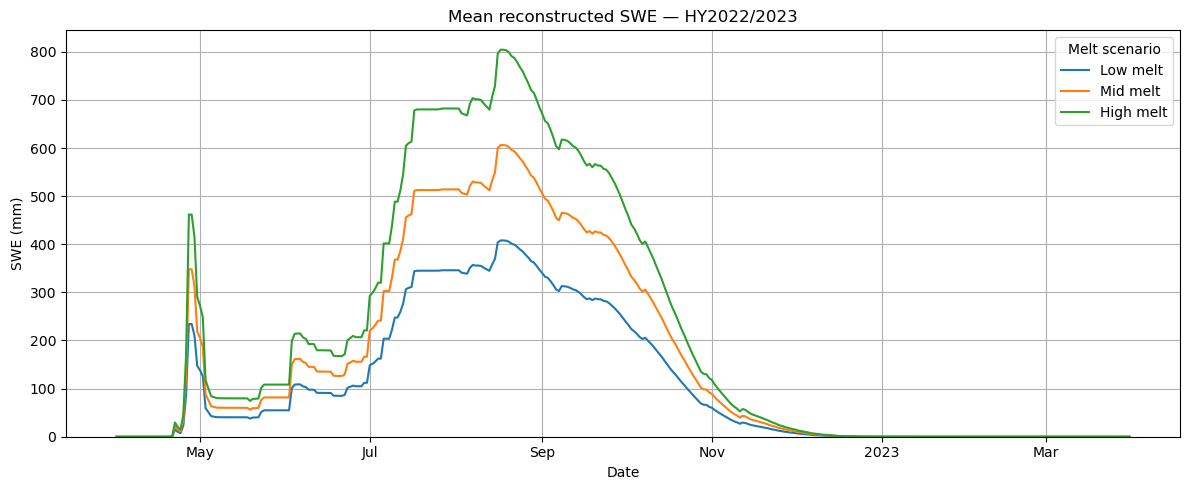

In [32]:
fig, ax = plt.subplots()

for scenario, result in scenario_results.items():
    result["mean_SWE"].plot(
        ax=ax,
        linewidth=1.5,
        label=scenario,
    )

ax.set(
    title=f"Mean reconstructed SWE — {HYDROLOGICAL_YEAR}",
    xlabel="Date",
    ylabel="SWE (mm)",
)
ax.set_ylim(bottom=0)
ax.legend(title="Melt scenario")
fig.tight_layout()
plt.show()

### Questions 

- Which factor has the strongest influence on peak SWE: `TF` or `SRF`? Change one factor at a time to find out.
- Do the factors change only the magnitude of SWE, or also the date of peak SWE?
